Measure first-order interest rate sensitivity

Measure second-order sensitivity

Understand duration as a weighted average maturity

Calculate bond and portfolio risk

Analyse exposure to specific points on the yield curve

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

In [181]:
from pathlib import Path

ROOT = Path.cwd().parent

In [182]:
curve = pd.read_csv(ROOT / "data/continuous_zero_curve.csv")
portfolio = pd.read_csv(ROOT / "data/sample_portfolio.csv")

display(curve)
display(portfolio)

,Years,Spot
0,0.250000,3.890000
1,0.309619,3.934183
2,0.369238,3.971005
3,0.428858,4.001286
4,0.488477,4.025844
...,...,...
495,29.761523,5.268275
496,29.821142,5.260573
497,29.880762,5.252767
498,29.940381,5.244856


,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight
0,2Y,2,2000000.0,4.20,99.886010,1.997720e+06,0.201218
1,5Y,5,3000000.0,4.27,99.554418,2.986633e+06,0.300825
2,7Y,7,1500000.0,4.37,99.342777,1.490142e+06,0.150093
3,10Y,10,2500000.0,4.49,98.961077,2.474027e+06,0.249193
4,20Y,20,1000000.0,4.95,97.961892,9.796189e+05,0.098671


In [183]:
spot_curve = CubicSpline(
    curve["Years"],
    curve["Spot"]
)

In [184]:
def discount_factor(t):

    r = spot_curve(t) / 100

    return 1 / (1 + r) ** t


def cashflows(maturity, coupon_rate, freq = 2, face = 100):

    periods = int(maturity * freq)

    payment = (coupon_rate / 100 * face / freq)

    times = np.arange(1, periods+1) / freq

    cashflows = np.full(
        periods,
        payment
    )

    cashflows[-1] += face

    return times, cashflows

def price_bond(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    dfs = discount_factor(times)

    return np.sum(cf * dfs)

def price_bond_curve(maturity, coupon_rate, curve, face = 100, frequency = 2):

    spline = CubicSpline(curve["Years"], curve["Spot"])

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    spot = spline(times) / 100

    discount = 1 / (1 + spot) ** times

    return np.sum(cf * discount)

def shift_curve(curve, shift_bp):

    shocked = curve.copy()

    shocked["Spot"] += shift_bp / 100

    return shocked

# Macaulay duration
def macaulay_duration(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency, face)

    df = discount_factor(times)

    pv = cf * df

    price = pv.sum()

    duration = np.sum(times * pv) / price

    return duration

# Effective duration
def eff_duration(maturity, coupon_rate, curve, face = 100, frequency = 2, dy = 1):

    curve_up = shift_curve(curve, dy)
    curve_down = shift_curve(curve, -dy)

    P_up = price_bond_curve(maturity, coupon_rate, curve_up, face, frequency)

    P_down = price_bond_curve(maturity, coupon_rate, curve_down, face, frequency)

    P0 = price_bond_curve(maturity, coupon_rate, curve, face, frequency)

    delta_y = dy / 10000

    return (P_down - P_up) / (2 * P0 * delta_y)

# Effective convexity via central difference
def eff_convexity(maturity, coupon_rate, curve, face = 100, frequency = 2, dy = 1):

    curve_up = shift_curve(curve, dy)
    curve_down = shift_curve(curve, -dy)

    P_up = price_bond_curve(maturity, coupon_rate, curve_up, face, frequency)
    
    P_down = price_bond_curve(maturity, coupon_rate, curve_down, face, frequency)

    P0 = price_bond_curve(maturity, coupon_rate, curve, face, frequency)

    delta_y = dy / 10000

    return (P_up + P_down - 2 * P0) / (P0 * delta_y ** 2)

# DV01 / PV01
def dv01(maturity, coupon_rate, curve, face = 100, frequency = 2):

    P0 = price_bond_curve(maturity, coupon_rate, curve, face, frequency)

    shocked = shift_curve(curve, 1)

    P1 = price_bond_curve(maturity, coupon_rate, shocked, face, frequency)

    return P0 - P1
    

In [185]:
portfolio["Duration"] = portfolio.apply(
    lambda row: eff_duration(
        row["Maturity"],
        row["Coupon"],
        curve
    ),
    axis=1
)

portfolio["Convexity"] = portfolio.apply(
    lambda row: eff_convexity(
        row["Maturity"],
        row["Coupon"],
        curve
    ),
    axis=1
)

portfolio["DV01"] = portfolio.apply(
    lambda row: (
        dv01(
            row["Maturity"],
            row["Coupon"],
            curve
        )
        * row["Face"] / 100
    ),
    axis=1
)


In [186]:
portfolio

,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight,Duration,Convexity,DV01
0,2Y,2,2000000.0,4.20,99.886010,1.997720e+06,0.201218,1.858975,5.300178,371.318172
1,5Y,5,3000000.0,4.27,99.554418,2.986633e+06,0.300825,4.360149,24.321737,1301.852947
2,7Y,7,1500000.0,4.37,99.342777,1.490142e+06,0.150093,5.833895,42.666887,869.015074
3,10Y,10,2500000.0,4.49,98.961077,2.474027e+06,0.249193,7.775469,76.129104,1922.730310
4,20Y,20,1000000.0,4.95,97.961892,9.796189e+05,0.098671,12.010601,200.537265,1175.598925


In [187]:
# Portfolio statistics
portfolio_duration = np.sum(
    portfolio["Weight"] * portfolio["Duration"]
)

portfolio_convexity = np.sum(
    portfolio["Weight"] * portfolio["Convexity"]
)

portfolio_dv01 = portfolio["DV01"].sum()

print(portfolio_duration)
print(portfolio_convexity)
print(portfolio_dv01)
display(portfolio)

5.684018662521254
53.545136343059276
5640.515428355215


,Bond,Maturity,Face,Coupon,Unit Price,Market Value,Weight,Duration,Convexity,DV01
0,2Y,2,2000000.0,4.20,99.886010,1.997720e+06,0.201218,1.858975,5.300178,371.318172
1,5Y,5,3000000.0,4.27,99.554418,2.986633e+06,0.300825,4.360149,24.321737,1301.852947
2,7Y,7,1500000.0,4.37,99.342777,1.490142e+06,0.150093,5.833895,42.666887,869.015074
3,10Y,10,2500000.0,4.49,98.961077,2.474027e+06,0.249193,7.775469,76.129104,1922.730310
4,20Y,20,1000000.0,4.95,97.961892,9.796189e+05,0.098671,12.010601,200.537265,1175.598925


In [188]:
# Compute KRD
def price_portfolio(portfolio, curve):

    total = 0

    for _, row in portfolio.iterrows():

        price = price_bond_curve(
            row["Maturity"],
            row["Coupon"],
            curve
        )

        total += (
            price
            * row["Face"]
            / 100
        )

    return total

def key_rate_shift(curve, maturity, shock_bp=1):

    shocked = curve.copy()

    idx = (shocked["Years"] - maturity).abs().idxmin()

    shocked.loc[idx, "Spot"] += shock_bp / 100

    return shocked



In [189]:
key_rates = [2,5,7,10,20]

base = price_portfolio(portfolio, curve)

krd = {}

for k in key_rates:

    shocked = key_rate_shift(curve, k, shock_bp = 1)

    shocked_price = price_portfolio(portfolio, shocked)

    krd[k] = (base - shocked_price) / (base * 0.0001) # delta_y = 1bp

In [190]:
krd = pd.DataFrame({

    "Key Rate": krd.keys(),

    "Duration": krd.values()

})

Text(0.5, 1.0, 'Key Rate Duration')

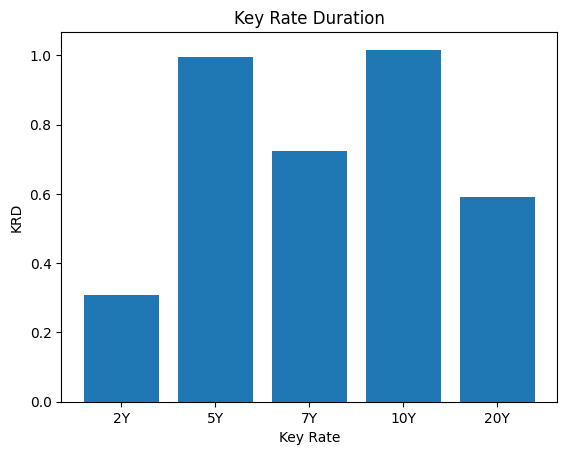

In [191]:
plt.bar(["2Y","5Y","7Y","10Y","20Y"], krd["Duration"])
plt.xlabel("Key Rate")
plt.ylabel("KRD")
plt.title("Key Rate Duration")

In [192]:
# Duration approximation
actual = []
duration_only = []
duration_convexity = []

P0 = price_portfolio(portfolio, curve)
D = portfolio_duration
C = portfolio_convexity

shifts = np.arange(-2, 2.25, 0.25)
for s in shifts:

    shocked = shift_curve(curve, s*100)

    actual.append(price_portfolio(portfolio, shocked)) # Reprice completely

    dy = s/100

    duration_only.append(

        P0 * (1 - D * dy)

    )

    duration_convexity.append(

        P0 * (1 - D * dy + 0.5 * C * dy ** 2)

    )

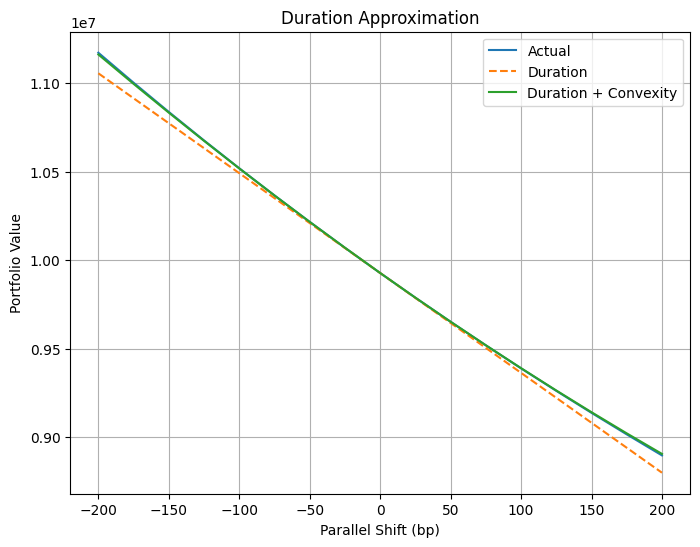

In [193]:
plt.figure(figsize=(8,6))

plt.plot(shifts * 100, actual, label = "Actual")

plt.plot(shifts * 100, duration_only, ls = "--", label = "Duration")

plt.plot(shifts * 100, duration_convexity, label = "Duration + Convexity")

plt.xlabel("Parallel Shift (bp)")
plt.ylabel("Portfolio Value")
plt.title("Duration Approximation")

plt.legend()
plt.grid()

In [194]:
# Risk summary
risk_summary = pd.DataFrame({

    "Metric":["Portfolio Value", "Effective Duration", "Effective Convexity", "Portfolio DV01"],
    "Value":[base_price, portfolio_duration, portfolio_convexity, portfolio_dv01]

})

risk_summary

,Metric,Value
0,Portfolio Value,9.928140e+06
1,Effective Duration,5.684019e+00
2,Effective Convexity,5.354514e+01
3,Portfolio DV01,5.640515e+03


In [195]:
risk_summary.to_csv(ROOT / "data/risk_summary.csv", index = False)